In [ ]:
# □石の縦方向の石の繋がりはまだできてない！ test2から、ここに関して改変中!
# □旧：シンプルに膨張幅で測定&上段の歪み補正はまだない

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import networkx as nx
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from scipy.signal import argrelextrema
from scipy.stats import gaussian_kde

In [2]:

# --- 一括管理するパス ---
image_path = "images/DJI_0471_resized.JPG" 
checkpoint_path = "sam_vit_b_01ec64.pth" 

# --- 解析パラメータ ---
DEFAULT_DILATE_PX = 10
DEFAULT_HEIGHT_RATIO = 0.5  # 歪み補正の強度（0.3~0.7）
STRUCTURAL_AREA_RATIO = 1.1 # 平均面積の何倍以上を「構造石」とみなすか

# ==========================================
#       SAM関連 & 基本関数
# ==========================================

def show_anns(anns):
    if len(anns) == 0: return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

def process_with_sam(image_path, model_checkpoint):
    print("--- SAM解析開始 ---")
    image = cv2.imread(image_path)
    if image is None:
        print(f"エラー: 画像が見つかりません: {image_path}")
        return None
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model_type = "vit_b"
    sam = sam_model_registry[model_type](checkpoint=model_checkpoint)
    sam.to(device=device)

    mask_generator = SamAutomaticMaskGenerator(
        model=sam,
        points_per_side=64,
        pred_iou_thresh=0.82,
        stability_score_thresh=0.88,
        min_mask_region_area=1000,
        crop_n_layers=0,
    )
    masks = mask_generator.generate(image)
    print(f"検出された石（領域）の数: {len(masks)}")
    return masks

def sort_masks_bottom_up(masks):
    return sorted(masks, key=lambda x: x['bbox'][1], reverse=True)

def visualize_labeled_masks(image, masks, title="Labeled Stones"):
    vis_img = image.copy()
    overlay = vis_img.copy()
    font = cv2.FONT_HERSHEY_SIMPLEX
    for i, mask in enumerate(masks):
        idx = i + 1
        y_indices, x_indices = np.where(mask['segmentation'])
        if len(y_indices) == 0: continue
        center_y = int(np.mean(y_indices))
        center_x = int(np.mean(x_indices))
        color = np.random.randint(0, 255, (3,)).tolist()
        overlay[mask['segmentation']] = color
        text = str(idx)
        cv2.putText(vis_img, text, (center_x-10, center_y+10), font, 0.7, (255, 255, 255), 2)
    cv2.addWeighted(overlay, 0.4, vis_img, 0.6, 0, vis_img)
    plt.figure(figsize=(10, 10))
    plt.imshow(vis_img)
    plt.title(title)
    plt.axis('off')
    plt.show()

def main():
    masks = process_with_sam(image_path, checkpoint_path)
    if masks is None: return None, None
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    current_masks = sort_masks_bottom_up(masks)
    
    while True:
        visualize_labeled_masks(image_rgb, current_masks, title=f"Check: {len(current_masks)} stones")
        print("【修正モード】削除番号を入力（例: '3 5'）。完了ならEnter。")
        user_input = input("削除番号 >> ")
        if not user_input.strip(): break
        try:
            remove_ids = set(map(int, user_input.split()))
            new_masks = [m for i, m in enumerate(current_masks) if (i + 1) not in remove_ids]
            current_masks = new_masks
            if len(current_masks) == 0: break
        except ValueError: print("数値を入力してください。")

    print("データフレームを作成中...")
    data_list = []
    for i, m in enumerate(current_masks):
        x, y, w, h = m['bbox']
        cx, cy = x + w / 2, y + h / 2
        data_list.append({'Stone_ID': i + 1, 'Area': m['area'], 'bbox': m['bbox'], 'Centroid_X': cx, 'Centroid_Y': cy})
    df = pd.DataFrame(data_list)
    print("メイン処理完了。")
    return current_masks, df

# ==========================================
#       新・段推定関数 (構造石判定 + 歪み補正)
# ==========================================

def apply_dynamic_tiering_v5(masks, df_stones, height_ratio=DEFAULT_HEIGHT_RATIO, dilate_px=DEFAULT_DILATE_PX):
    """
    動的閾値による段推定を行い、かつ構造石(is_structural)の判定も行う
    """
    print(f"\n--- 動的ティアリング解析 (歪み補正: Ratio={height_ratio}) ---")
    df_work = df_stones.copy()
    
    # 1. 構造石の特定（描画で使うためここで計算）
    avg_area = df_work['Area'].mean()
    df_work['is_structural'] = df_work['Area'] > (avg_area * STRUCTURAL_AREA_RATIO)
    print(f"構造石の数: {df_work['is_structural'].sum()}")

    # 2. 段推定の準備
    df_work['Tier'] = -1
    df_work['mask_index'] = df_stones.index 
    df_work = df_work.sort_values('Centroid_Y', ascending=False)
    processed_indices = set()
    current_tier = 1
    
    dilated_masks_cache = {}
    kernel = np.ones((dilate_px, dilate_px), np.uint8)
    for idx in df_work.index:
        m_idx = int(df_work.loc[idx, 'mask_index'])
        dilated_masks_cache[idx] = cv2.dilate(masks[m_idx]['segmentation'].astype(np.uint8), kernel, iterations=1)

    # 3. ボトムアップ探索
    for i in range(len(df_work)):
        target_idx = df_work.index[i]
        if target_idx in processed_indices: continue
            
        queue = [target_idx]
        processed_indices.add(target_idx)
        df_work.at[target_idx, 'Tier'] = current_tier
        
        q_idx = 0
        while q_idx < len(queue):
            curr_idx = queue[q_idx]
            q_idx += 1
            curr_row = df_work.loc[curr_idx]
            h_curr = curr_row['bbox'][3]
            
            for other_idx in df_work.index:
                if other_idx == curr_idx: continue
                other_row = df_work.loc[other_idx]
                h_other = other_row['bbox'][3]
                
                # 動的閾値（歪み補正）
                avg_height = (h_curr + h_other) / 2
                dynamic_threshold = avg_height * height_ratio
                
                if abs(curr_row['Centroid_Y'] - other_row['Centroid_Y']) < dynamic_threshold:
                    m_idx_j = int(other_row['mask_index'])
                    if np.any(np.logical_and(dilated_masks_cache[curr_idx], masks[m_idx_j]['segmentation'])):
                        if other_idx not in processed_indices:
                            df_work.at[other_idx, 'Tier'] = current_tier
                            processed_indices.add(other_idx)
                            queue.append(other_idx)
        current_tier += 1
    
    # 4. ティア正規化
    unique_tiers = sorted(df_work['Tier'].unique()) 
    tier_map = {old: new + 1 for new, old in enumerate(unique_tiers)}
    df_work['Tier'] = df_work['Tier'].map(tier_map)
    
    # KDE計算（右図用）
    y_values = df_work['Centroid_Y'].values
    kde = gaussian_kde(y_values, bw_method=0.15)
    y_grid = np.linspace(y_values.min()-50, y_values.max()+50, 1000)
    y_density = kde(y_grid)
    
    return df_work, y_grid, y_density



--- SAM解析開始 ---
検出された石（領域）の数: 244


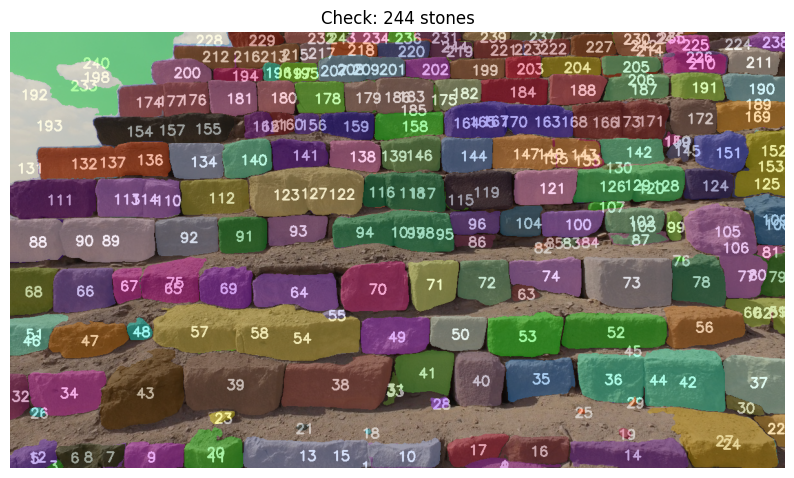

【修正モード】削除番号を入力（例: '3 5'）。完了ならEnter。


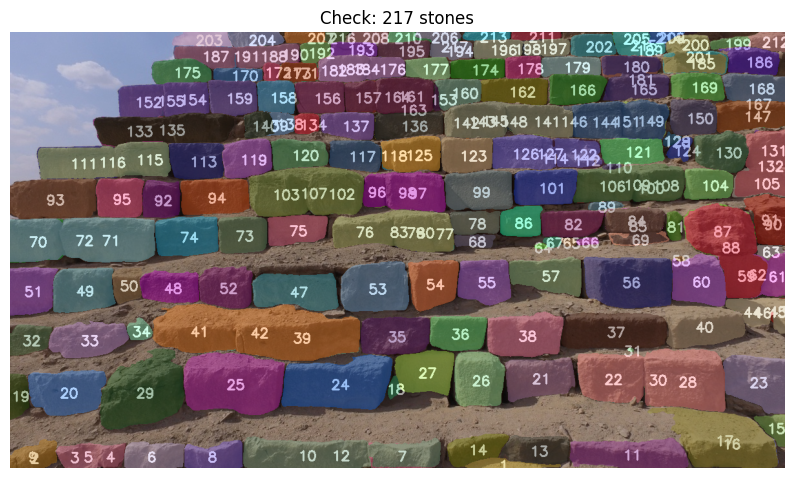

【修正モード】削除番号を入力（例: '3 5'）。完了ならEnter。


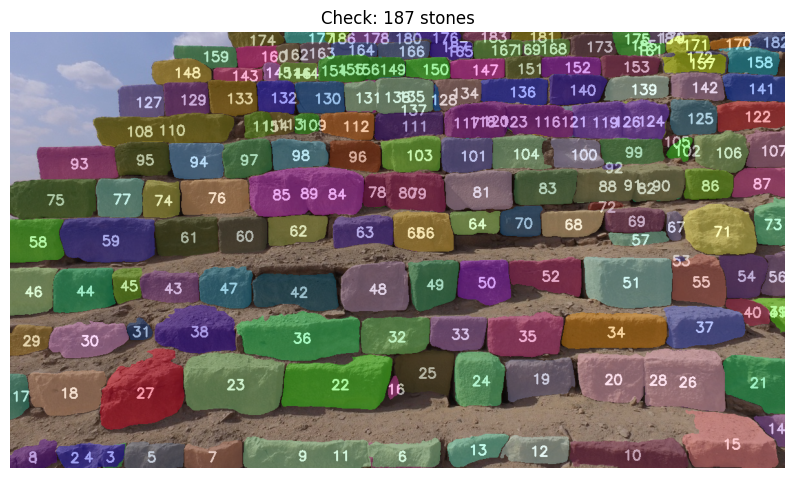

【修正モード】削除番号を入力（例: '3 5'）。完了ならEnter。


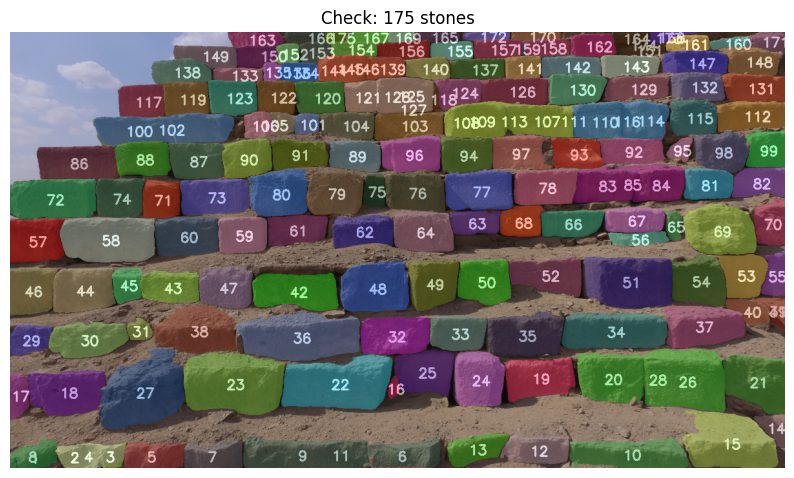

【修正モード】削除番号を入力（例: '3 5'）。完了ならEnter。


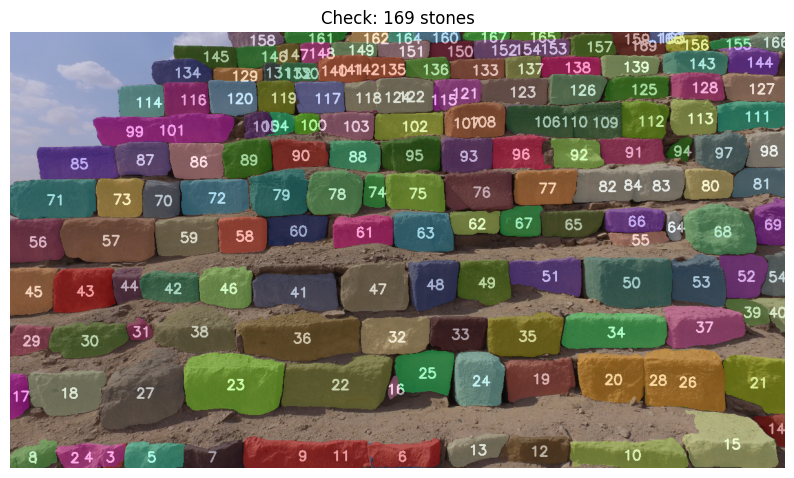

【修正モード】削除番号を入力（例: '3 5'）。完了ならEnter。


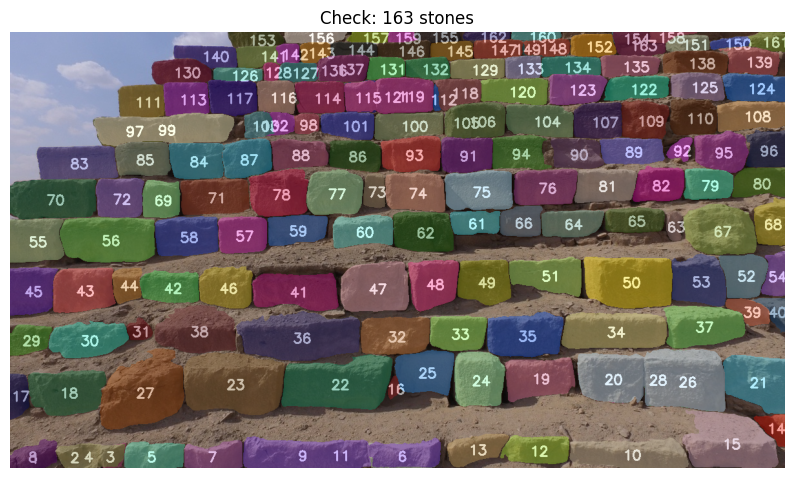

【修正モード】削除番号を入力（例: '3 5'）。完了ならEnter。


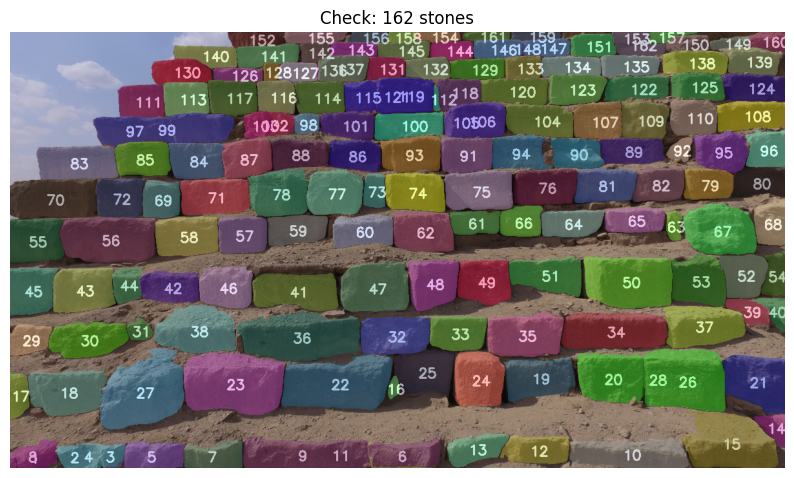

【修正モード】削除番号を入力（例: '3 5'）。完了ならEnter。


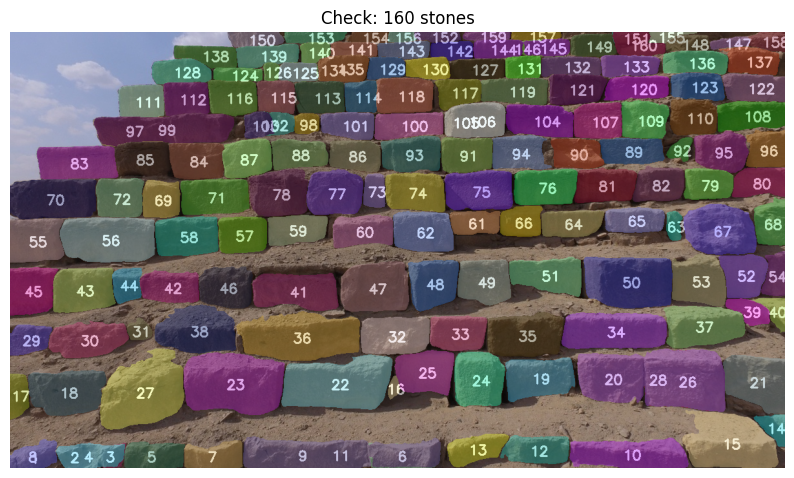

【修正モード】削除番号を入力（例: '3 5'）。完了ならEnter。
データフレームを作成中...
メイン処理完了。

--- 動的ティアリング解析 (歪み補正: Ratio=0.5) ---
構造石の数: 52

--- ティア別解析結果 ---
Tier
16     7
15    16
14    14
13    13
12    12
11     2
10    14
9     14
8      9
7      5
6     14
5     12
4      4
3      9
2      5
1     10
Name: count, dtype: int64


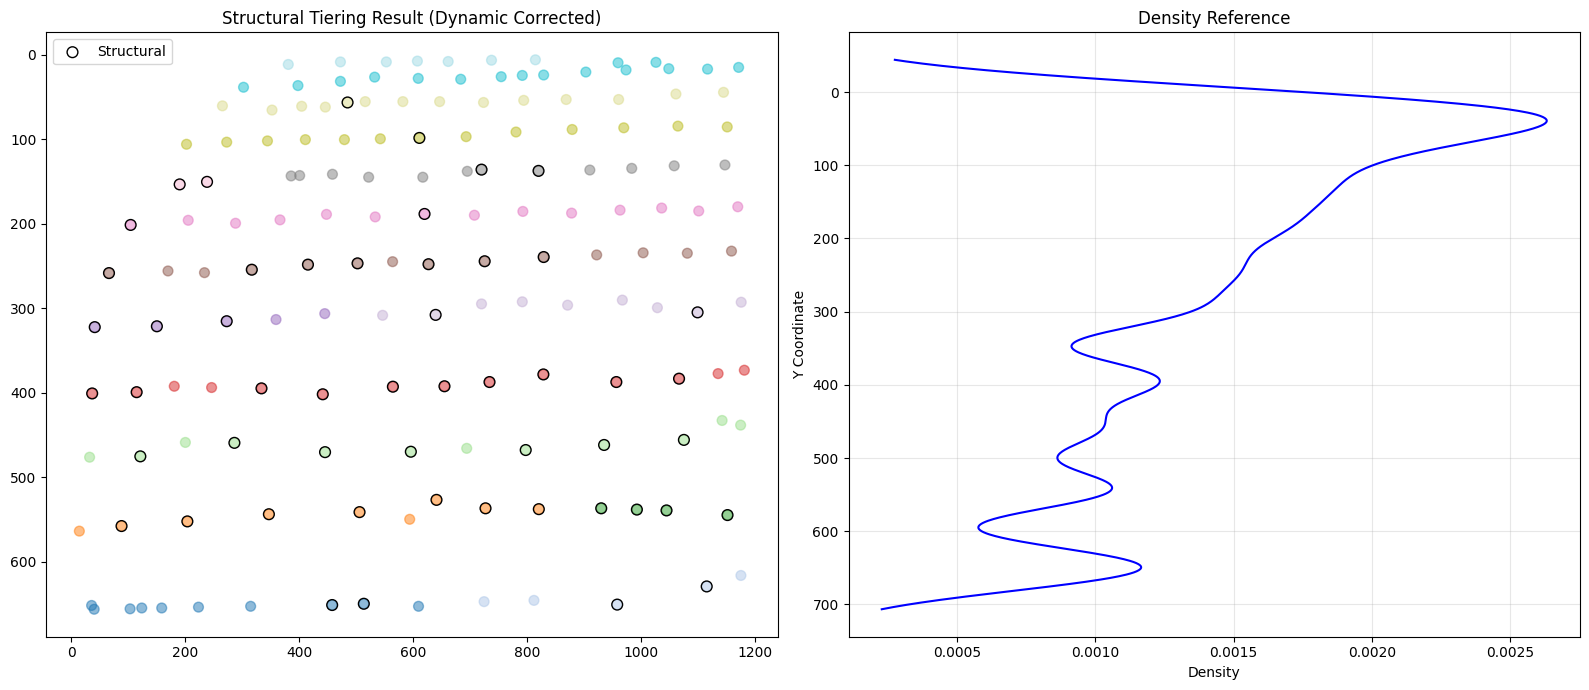

In [3]:
# ==========================================
#       実行ブロック
# ==========================================
if __name__ == "__main__":
    current_masks, df = main() 

    if current_masks is not None:
        # 動的ティアリング実行
        df, y_grid, y_density = apply_dynamic_tiering_v5(current_masks, df)
        
        print("\n--- ティア別解析結果 ---")
        print(df['Tier'].value_counts().sort_index(ascending=False))

        # --- 可視化（ご希望のスタイル） ---
        fig, ax = plt.subplots(1, 2, figsize=(16, 7))

        # [左図] 空間プロット (背景なし、シンプル版)
        ax[0].invert_yaxis() # Y軸反転
        
        # 全石を表示（段ごとに色分け）
        scatter = ax[0].scatter(df['Centroid_X'], df['Centroid_Y'], c=df['Tier'], cmap='tab20', s=50, alpha=0.5)
        
        # 構造石のみ枠線を付けて強調
        if 'is_structural' in df.columns:
            struct_df = df[df['is_structural']]
            ax[0].scatter(struct_df['Centroid_X'], struct_df['Centroid_Y'], c='none', edgecolors='black', s=60, label='Structural')
        
        ax[0].set_title("Structural Tiering Result (Dynamic Corrected)")
        ax[0].legend()

        # [右図] 密度グラフ
        ax[1].plot(y_density, y_grid, color='blue', label='Vertical Density')
        ax[1].invert_yaxis()
        ax[1].set_title("Density Reference")
        ax[1].set_xlabel("Density")
        ax[1].set_ylabel("Y Coordinate")
        ax[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

--- アノテーション修正を再開します (現在の石数: 160) ---


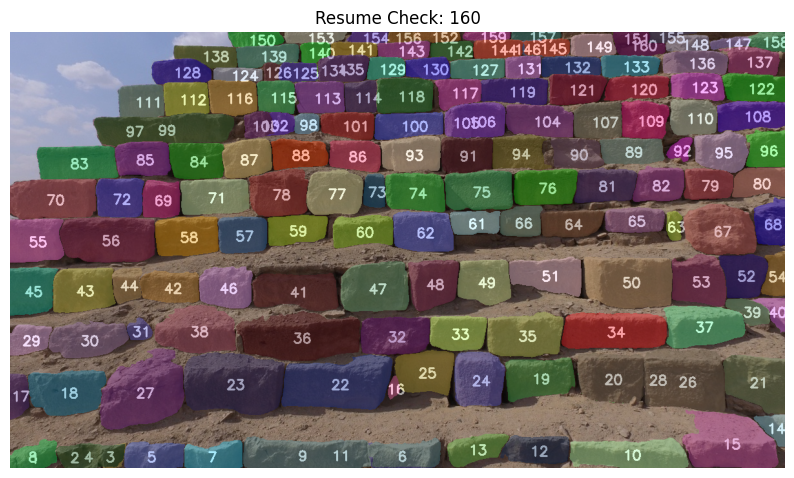

削除したい石の番号を入力 (完了ならEnter)
データベース(df)を再構築中...
動的ティアリング解析を再実行中...

--- 動的ティアリング解析 (歪み補正: Ratio=0.5) ---
構造石の数: 52

--- 最新の解析結果 ---
Tier
16     7
15    16
14    14
13    13
12    12
11     2
10    14
9     14
8      9
7      5
6     14
5     12
4      4
3      9
2      5
1     10
Name: count, dtype: int64


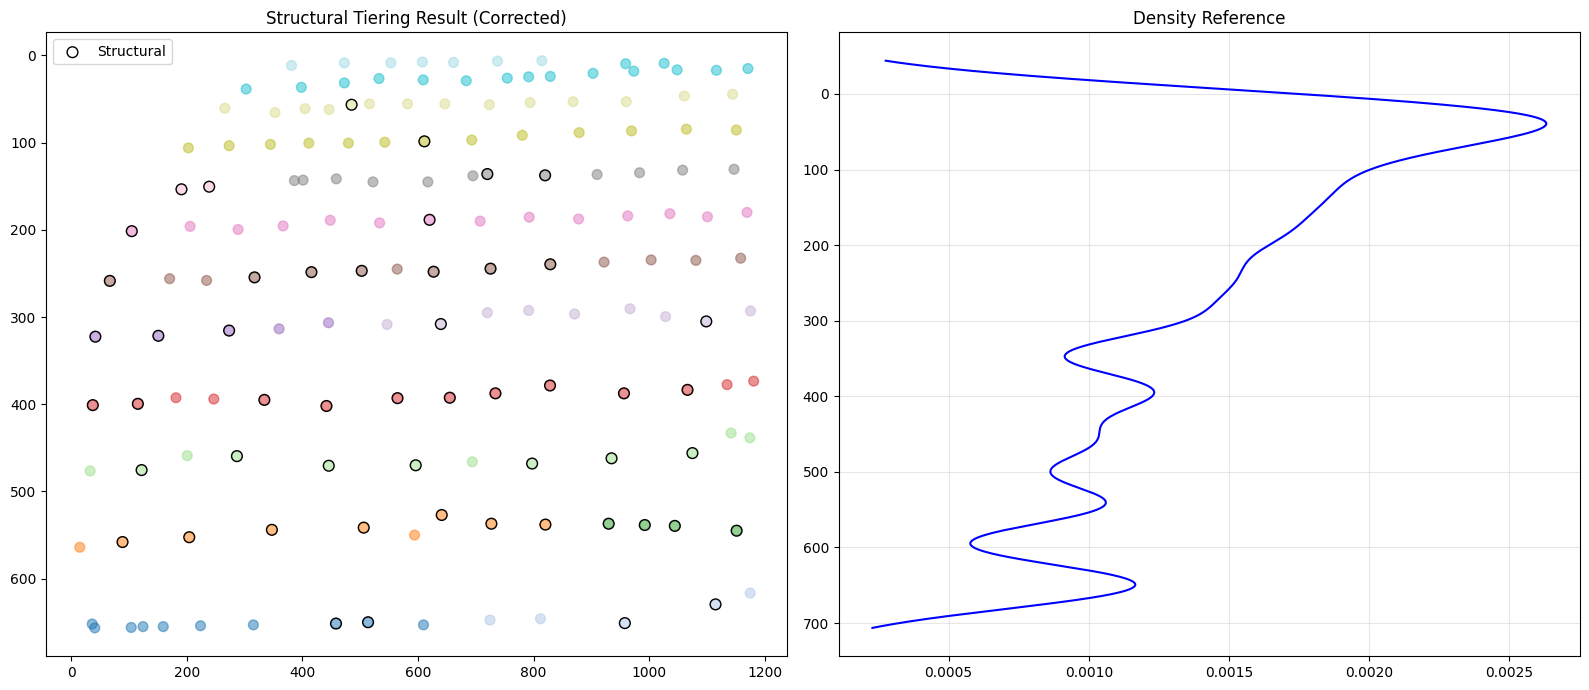

In [4]:
# --- アノテーション再開・データベース更新・再描画ブロック ---

if __name__ == "__main__":
    if 'current_masks' in locals() and current_masks is not None:
        print(f"--- アノテーション修正を再開します (現在の石数: {len(current_masks)}) ---")
        
        # 画像準備
        if os.path.exists(image_path):
            img = cv2.imread(image_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # --- 修正ループ ---
            while True:
                visualize_labeled_masks(img_rgb, current_masks, title=f"Resume Check: {len(current_masks)}")
                print("削除したい石の番号を入力 (完了ならEnter)")
                user_input = input("削除番号 >> ").strip()
                if not user_input: break
                try:
                    remove_ids = set(map(int, user_input.split()))
                    current_masks = [m for i, m in enumerate(current_masks) if (i + 1) not in remove_ids]
                except ValueError: print("数値を入力してください。")
            
            # --- データベース更新 ---
            print("データベース(df)を再構築中...")
            current_masks = sort_masks_bottom_up(current_masks)
            data_list = []
            for i, m in enumerate(current_masks):
                x, y, w, h = m['bbox']
                data_list.append({
                    'Stone_ID': i + 1, 'Area': m['area'], 'bbox': m['bbox'],
                    'Centroid_X': x + w / 2, 'Centroid_Y': y + h / 2
                })
            df = pd.DataFrame(data_list)
            
            # --- 段推定の再実行 (動的補正版) ---
            print("動的ティアリング解析を再実行中...")
            # ここで 'is_structural' も計算されます
            df, y_grid, y_density = apply_dynamic_tiering_v5(current_masks, df)

            # --- 結果の可視化 (シンプルスタイル) ---
            print("\n--- 最新の解析結果 ---")
            print(df['Tier'].value_counts().sort_index(ascending=False))

            fig, ax = plt.subplots(1, 2, figsize=(16, 7))

            # [左図] 空間プロット
            ax[0].invert_yaxis()
            ax[0].scatter(df['Centroid_X'], df['Centroid_Y'], c=df['Tier'], cmap='tab20', s=50, alpha=0.5)
            
            # 構造石の強調
            if 'is_structural' in df.columns:
                struct_df = df[df['is_structural']]
                ax[0].scatter(struct_df['Centroid_X'], struct_df['Centroid_Y'], c='none', edgecolors='black', s=60, label='Structural')
            
            ax[0].set_title("Structural Tiering Result (Corrected)")
            ax[0].legend()

            # [右図] 密度グラフ
            ax[1].plot(y_density, y_grid, color='blue')
            ax[1].invert_yaxis()
            ax[1].set_title("Density Reference")
            ax[1].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()
            
        else:
            print(f"エラー: 画像が見つかりません {image_path}")
    else:
        print("エラー: current_masks がありません。先にSAMを実行してください。")

In [5]:
# ---　フェーズ2：グラフ構造化と解析結果の出力　---


#膨張幅　　(現状: 10  少し広げる: 15  かなり広げる: 20 〜 25)
DEFAULT_DILATE_PX = 80
DEFAULT_Y_THRESHOLD = 40


def analyze_horizontal_order_v4(df_stones, masks, dilate_px=10):#水平方向の順序付けと隣接グラフ構築(すでに段（Tier）が決まっているデータに対し、各段の中で「左から右」へ順位（Horizontal_Rank）を振ります。)
    #また、石を少し膨張させて隣り合っている石同士を見つけ、グラフ（ネットワーク）を作ります。

    #df_stonesとmasksが1対1で対応していることを前提に、安全にインデックスを管理して隣接グラフを構築する。
    
    print("\n--- 水平方向の解析（インデックス同期版）開始 ---")
    
    # 1. データフレームのインデックスを振り直し、マスクとの順序を固定する
    # main()から返された直後であれば、df_stonesのi行目はmasksのi番目に対応している
    df_working = df_stones.copy().reset_index(drop=True)
    
    # 2. 垂直方向の段(Tier)でグループ化した後、各段の中で左から順に並べる
    # 注意: ここでソートするとmasksとの順序が崩れるため、
    # masksの元の位置を保持するための 'original_idx' を作っておく
    df_working['original_idx'] = df_working.index 
    
    # 段(Tier) -> X座標 の順でソートして順位を決定
    df_sorted = df_working.sort_values(['Tier', 'Centroid_X']).copy()
    df_sorted['Horizontal_Rank'] = df_sorted.groupby('Tier').cumcount() + 1
    
    # 3. 隣接グラフの構築
    G = nx.Graph()
    for idx, row in df_sorted.iterrows():
        # 描画用に Stone_ID をノード名にする
        G.add_node(row['Stone_ID'], pos=(row['Centroid_X'], row['Centroid_Y']), 
                   tier=row['Tier'], rank=row['Horizontal_Rank'])

    # 4. 隣接判定（元のインデックスを使用してマスクにアクセス）
    print(f"隣接関係を計算中... (対象石数: {len(df_sorted)})")
    
    # 効率のため、一度全マスクを膨張させたものをリスト化する
    dilated_masks = []
    kernel = np.ones((dilate_px, dilate_px), np.uint8)
    for i in range(len(df_working)):
        m = masks[i]['segmentation'].astype(np.uint8)
        dilated_masks.append(cv2.dilate(m, kernel, iterations=1))

    # 二重ループで接触判定
    stone_rows = [row for _, row in df_sorted.iterrows()]
    for i in range(len(stone_rows)):
        row_i = stone_rows[i]
        idx_i = int(row_i['original_idx']) # 元のリスト位置
        id_i = row_i['Stone_ID']
        
        for j in range(i + 1, len(stone_rows)):
            row_j = stone_rows[j]
            idx_j = int(row_j['original_idx']) # 元のリスト位置
            id_j = row_j['Stone_ID']
            
            # 膨張させたマスクiと、通常のマスクjの重なりをチェック
            if np.any(np.logical_and(dilated_masks[idx_i], masks[idx_j]['segmentation'])):
                G.add_edge(id_i, id_j)
                

    return df_sorted, G




def analyze_tiering_bottom_up(df_stones, masks, y_threshold=DEFAULT_Y_THRESHOLD, dilate_px=DEFAULT_DILATE_PX):
    #ボトムアップ・チェイン法による構造解析
    
    print("\n--- ボトムアップ・チェイン法（隣接エッジ構築）開始 ---")
    
    df_work = df_stones.copy()
    df_work['Tier'] = -1
    # 元のリスト順序を保持（IndexError対策）
    df_work['mask_index'] = df_stones.index 
    df_work = df_work.sort_values('Centroid_Y', ascending=False)
    
    # 隣接グラフの初期化
    G = nx.Graph()
    for _, row in df_stones.iterrows():
        G.add_node(row['Stone_ID'], pos=(row['Centroid_X'], row['Centroid_Y']))
    
    current_tier = 1
    processed_indices = set()
    
    # --- 1. 水平方向（同じ段）の判定とTierの確定 ---
    for i in range(len(df_work)):
        target_idx = df_work.index[i]
        if target_idx in processed_indices:
            continue
            
        queue = [target_idx]
        processed_indices.add(target_idx)
        df_work.at[target_idx, 'Tier'] = current_tier
        
        q_idx = 0
        while q_idx < len(queue):
            curr_idx = queue[q_idx]
            q_idx += 1
            curr_row = df_work.loc[curr_idx]
            
            m_idx_i = int(curr_row['mask_index'])
            mask_i = masks[m_idx_i]['segmentation'].astype(np.uint8)
            dilated_i = cv2.dilate(mask_i, np.ones((dilate_px, dilate_px), np.uint8), iterations=1)
            
            for other_idx in df_work.index:
                if other_idx == curr_idx: continue
                
                other_row = df_work.loc[other_idx]
                
                # 同一段の条件：高さが近く、かつ物理的に接触している
                if abs(curr_row['Centroid_Y'] - other_row['Centroid_Y']) < y_threshold:
                    m_idx_j = int(other_row['mask_index'])
                    if np.any(np.logical_and(dilated_i, masks[m_idx_j]['segmentation'])):
                        # 【変更点】エッジに属性 'horizontal' を付与
                        G.add_edge(curr_row['Stone_ID'], other_row['Stone_ID'], type='horizontal')
                        
                        if other_idx not in processed_indices:
                            df_work.at[other_idx, 'Tier'] = current_tier
                            processed_indices.add(other_idx)
                            queue.append(other_idx)
        current_tier += 1
    
    # 正規化とランク付け
    unique_tiers = sorted(df_work['Tier'].unique()) 
    tier_map = {old: new + 1 for new, old in enumerate(unique_tiers)}
    df_work['Tier'] = df_work['Tier'].map(tier_map)
    
    df_work = df_work.sort_values(['Tier', 'Centroid_X'])
    df_work['Horizontal_Rank'] = df_work.groupby('Tier').cumcount() + 1
    
    # --- 2. 垂直方向（上下の支持関係）の判定 ---
    print("垂直支持関係（Vertical Support）を解析中...")
    
    # 高速化のため、全マスクの膨張版を辞書化
    dilated_masks_cache = {}
    kernel = np.ones((dilate_px, dilate_px), np.uint8)
    for idx in df_work.index:
        m_idx = int(df_work.loc[idx, 'mask_index'])
        dilated_masks_cache[idx] = cv2.dilate(masks[m_idx]['segmentation'].astype(np.uint8), kernel, iterations=1)

    # 全探索（ただし Tier + 1 の石だけをチェック）
    for i, row_i in df_work.iterrows():
        current_tier_val = row_i['Tier']
        upper_tier_val = current_tier_val + 1
        
        # 1つ上の段にある石だけを抽出
        upper_candidates = df_work[df_work['Tier'] == upper_tier_val]
        
        for j, row_j in upper_candidates.iterrows():
            # 接触判定
            overlap = np.any(np.logical_and(
                dilated_masks_cache[i], 
                masks[int(row_j['mask_index'])]['segmentation']
            ))
            
            if overlap:
                # 【追加点】エッジに属性 'vertical' を付与
                G.add_edge(row_i['Stone_ID'], row_j['Stone_ID'], type='vertical')

    print(f"推定完了: {df_work['Tier'].max()} 段を検出しました。")
    return df_work, G







def visualize_bottom_up(image_rgb, df_stones, G_tier=None, font_size=24):
    """
    結果の可視化（文字強調版＋垂直エッジ対応）
    """
    fig, ax = plt.subplots(figsize=(20, 14))
    ax.imshow(image_rgb)
    
    if 'Horizontal_Rank' not in df_stones.columns:
         df_stones = df_stones.sort_values(['Tier', 'Centroid_X'])
         df_stones['Horizontal_Rank'] = df_stones.groupby('Tier').cumcount() + 1
    
    # エッジの描画（タイプ別に色分け）
    if G_tier is not None:
         pos = nx.get_node_attributes(G_tier, 'pos')
         
         # 水平エッジ（同じ段）を抽出
         h_edges = [(u, v) for u, v, d in G_tier.edges(data=True) if d.get('type') == 'horizontal']
         # 垂直エッジ（上下関係）を抽出（typeがない古いエッジも考慮してelseで拾うか、明示的に指定）
         v_edges = [(u, v) for u, v, d in G_tier.edges(data=True) if d.get('type') == 'vertical']
         # 上記以外（後方互換用）
         other_edges = [(u, v) for u, v, d in G_tier.edges(data=True) if 'type' not in d]

         # 描画: 水平は「白」、垂直は「赤(または黄色)」
         nx.draw_networkx_edges(G_tier, pos, ax=ax, edgelist=h_edges + other_edges,
                                alpha=0.4, edge_color='white', width=1.5, label='Horizontal')
         nx.draw_networkx_edges(G_tier, pos, ax=ax, edgelist=v_edges,
                                alpha=0.6, edge_color='#FF3333', width=2.0, style='dashed', label='Vertical')

    for _, row in df_stones.iterrows():
        color = plt.cm.get_cmap('tab20')(int(row['Tier']) % 20)
        
        radius = font_size * 0.7
        
        circle = plt.Circle((row['Centroid_X'], row['Centroid_Y']), radius, 
                            color=color, ec='black', lw=2, alpha=0.7, zorder=5)
        ax.add_patch(circle)

        ax.text(row['Centroid_X'], row['Centroid_Y'], str(int(row['Stone_ID'])), 
                color='black',
                ha='center', va='center', 
                fontsize=font_size * 0.7, 
                zorder=6)

    plt.title("Structural Analysis: Horizontal (White) & Vertical Support (Red)", fontsize=18)
    plt.axis('off')
    # 凡例を表示してわかりやすくする
    # ダミーの線を作って凡例に追加
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='white', lw=1.5, label='Horizontal (Same Tier)'),
        Line2D([0], [0], color='#FF3333', lw=2.0, linestyle='--', label='Vertical (Support)')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=12)
    
    plt.show()

    

#-------------------------------------------------------------------------------------

def print_analysis_summary(df_results): #解析結果のフィードバックを行う関数
    print("========================================")
    print("          ピラミッド解析サマリー         ")
    print("========================================")
    
    total_stones = len(df_results)
    tiers = sorted(df_results['Tier'].unique(), reverse=True)
    total_tiers = len(tiers)
    
    print(f"■ 認識された石の総数 : {total_stones} 個")
    print(f"■ 認識された総段数   : {total_tiers} 段")
    print("-" * 40)
    
    print("■ 各段の石の配列（左から右）")
    for t in tiers:
        tier_stones = df_results[df_results['Tier'] == t].sort_values('Horizontal_Rank')
        stone_ids = tier_stones['Stone_ID'].astype(int).astype(str).tolist()
        tier_line = " - ".join(stone_ids)
        print(f"Tier {int(t):>2} : {tier_line}")
    print("========================================\n")



def search_stone_info(target_id, df_results, masks, dilate_px=DEFAULT_DILATE_PX):#指定した石(番号)の詳細情報を出力する関数
    stone_data = df_results[df_results['Stone_ID'] == target_id]
    
    if stone_data.empty:
        print(f"× 石番号 {target_id} は見つかりません。")
        return

    row = stone_data.iloc[0]
    m_idx = int(row['mask_index'])
    
    print(f"【石番号 {target_id} の詳細解析データ】")
    print(f"----------------------------------------")
    print(f"・面積         : {row['Area']:.2f} px²")
    print(f"・推定位置     : {int(row['Tier'])} 段目の {int(row['Horizontal_Rank'])} 番目 (左から)")
    print(f"・重心座標     : (X: {row['Centroid_X']:.1f}, Y: {row['Centroid_Y']:.1f})")
    
    mask_i = masks[m_idx]['segmentation'].astype(np.uint8)
    kernel = np.ones((dilate_px, dilate_px), np.uint8)
    dilated_i = cv2.dilate(mask_i, kernel, iterations=1)
    
    adj_lr = []
    adj_ud = []
    
    my_tier = row['Tier']
    
    for _, other in df_results.iterrows():
        if other['Stone_ID'] == target_id: continue
        
        m_idx_j = int(other['mask_index'])
        if np.any(np.logical_and(dilated_i, masks[m_idx_j]['segmentation'])):
            other_id = int(other['Stone_ID'])
            if other['Tier'] == my_tier:
                adj_lr.append(other_id)
            else:
                adj_ud.append(other_id)
                
    print(f"・隣接（左右） : {adj_lr if adj_lr else 'なし'}")
    print(f"・隣接（上下） : {adj_ud if adj_ud else 'なし'}")
    print(f"----------------------------------------")


--- ボトムアップ・チェイン法（隣接エッジ構築）開始 ---
垂直支持関係（Vertical Support）を解析中...
推定完了: 8 段を検出しました。


/var/folders/p1/y3txcf3s2wq_l30gfj6xb62r0000gn/T/ipykernel_67108/730467311.py:200: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap('tab20')(int(row['Tier']) % 20)


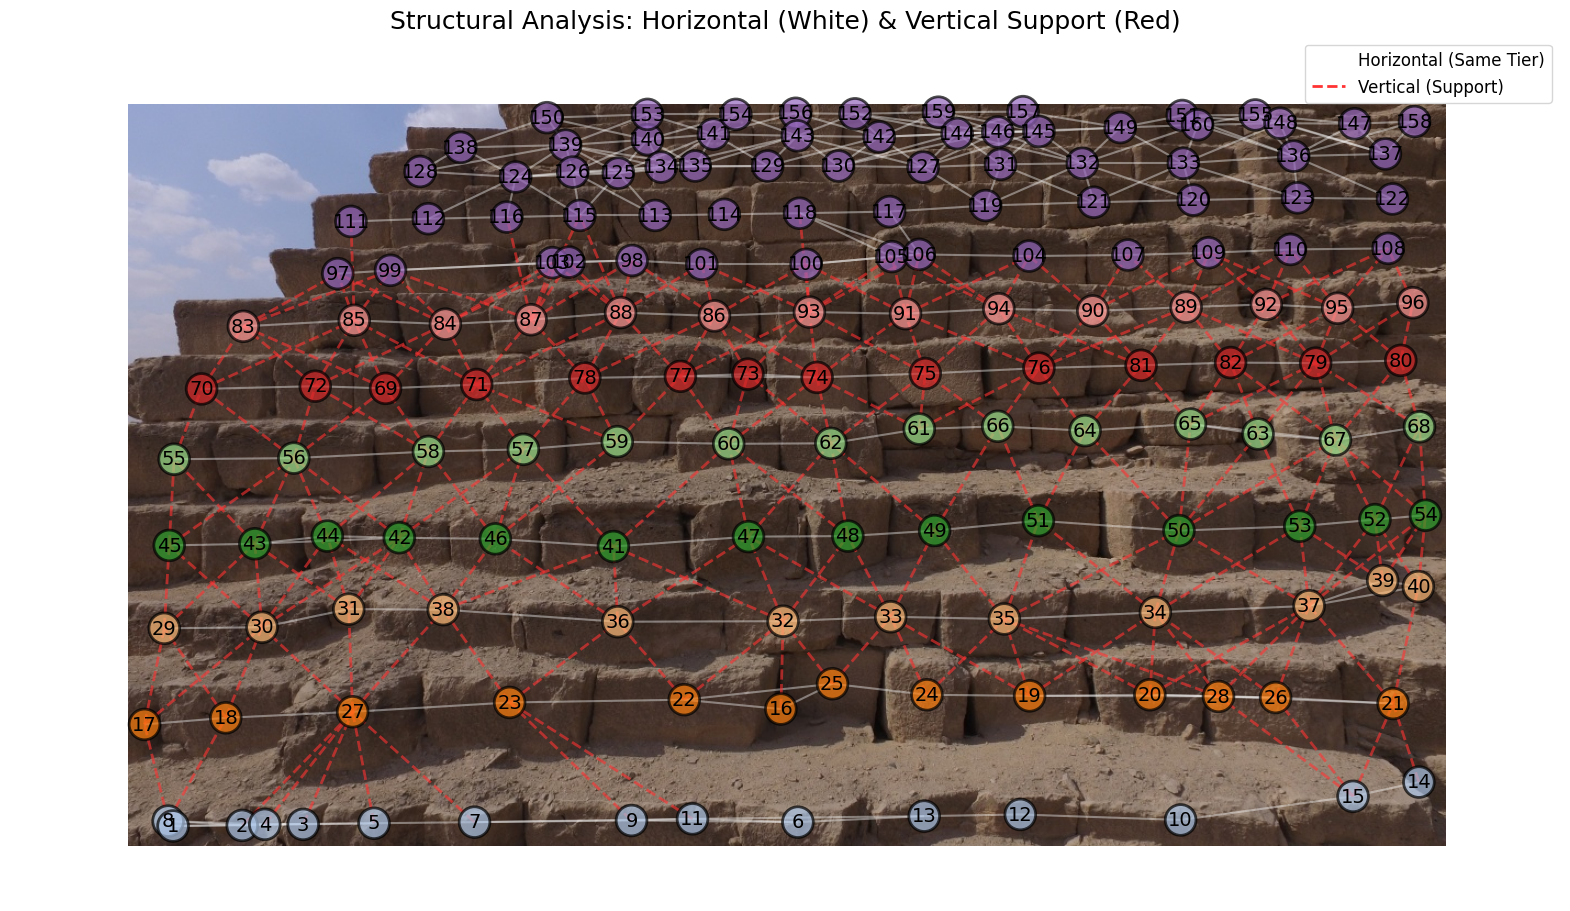

解析結果を bottom_up_result.csv に保存しました。
          ピラミッド解析サマリー         
■ 認識された石の総数 : 160 個
■ 認識された総段数   : 8 段
----------------------------------------
■ 各段の石の配列（左から右）
Tier  8 : 97 - 111 - 99 - 128 - 112 - 138 - 116 - 124 - 150 - 103 - 139 - 102 - 126 - 115 - 125 - 98 - 140 - 153 - 113 - 134 - 135 - 101 - 141 - 114 - 154 - 129 - 156 - 143 - 118 - 100 - 130 - 152 - 142 - 117 - 105 - 106 - 127 - 159 - 144 - 119 - 146 - 131 - 157 - 104 - 145 - 132 - 121 - 149 - 107 - 151 - 133 - 120 - 160 - 109 - 155 - 148 - 110 - 136 - 123 - 147 - 137 - 108 - 122 - 158
Tier  7 : 83 - 85 - 84 - 87 - 88 - 86 - 93 - 91 - 94 - 90 - 89 - 92 - 95 - 96
Tier  6 : 70 - 72 - 69 - 71 - 78 - 77 - 73 - 74 - 75 - 76 - 81 - 82 - 79 - 80
Tier  5 : 55 - 56 - 58 - 57 - 59 - 60 - 62 - 61 - 66 - 64 - 65 - 63 - 67 - 68
Tier  4 : 45 - 43 - 44 - 42 - 46 - 41 - 47 - 48 - 49 - 51 - 50 - 53 - 52 - 54
Tier  3 : 29 - 30 - 31 - 38 - 36 - 32 - 33 - 35 - 34 - 37 - 39 - 40
Tier  2 : 17 - 18 - 27 - 23 - 22 - 16 - 25 - 24 - 19 - 20 - 28 - 26 

In [6]:
# フェーズ2の実行
if __name__ == "__main__":

    if 'current_masks' in locals() and 'df' in locals() and current_masks is not None:
        
        # 1. ボトムアップ法による推定
        # y_thresholdやdilate_pxはデフォルト定数が使われますが、必要なら引数で上書き可能
        df_final, G_tier = analyze_tiering_bottom_up(df, current_masks)
        
        # 2. 結果の可視化
        img_path = "images/DJI_0471_resized.JPG" 

        if os.path.exists(img_path):
            image_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
            visualize_bottom_up(image_rgb, df_final, G_tier, font_size=20)
            
            # 3. CSV保存
            df_final.to_csv("bottom_up_result.csv", index=False)
            print("解析結果を bottom_up_result.csv に保存しました。")
        
        # 4. サマリー表示
        print_analysis_summary(df_final)
        
    else:
        print("エラー: フェーズ1が完了していないか、データがありません。#1.2を実行してください。")

In [ ]:
# --- 石の詳細検索実行ブロック ---

if __name__ == "__main__":
    # 解析済みデータが存在するかチェック
    # 基本的にはフェーズ2完了後の 'df_final' を使いますが、なければフェーズ1の 'df' を代用します
    target_df = None
    if 'df_final' in locals() and df_final is not None:
        target_df = df_final
    elif 'df' in locals() and df is not None:
        target_df = df
        print("※警告: フェーズ2（Tier推定）が未完了のため、段数や隣接情報は表示されないか不正確です。")
    
    # データとマスクがある場合のみ実行
    if target_df is not None and 'current_masks' in locals() and current_masks is not None:
        print("【石詳細検索モード】")
        
        while True:
            print("\n" + "-"*40)
            user_input = input("詳細を見たい石の番号(Stone_ID)を入力してください (終了は 'q' または Enter): ").strip()
            
            # 終了判定
            if not user_input or user_input.lower() == 'q':
                print("検索を終了します。")
                break
            
            try:
                # 入力を整数に変換して関数を呼び出す
                target_id = int(user_input)
                search_stone_info(target_id, target_df, current_masks)
                
            except ValueError:
                print("エラー: 数値を入力してください。")
            except Exception as e:
                print(f"予期せぬエラーが発生しました: {e}")
                
    else:
        print("エラー: 解析データが見つかりません。先にフェーズ1またはフェーズ2を実行してください。")